In [2]:
# Preprocessing + Tokenization
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn

df = pd.read_csv("/content/Combined.csv")   # change path if needed

df = df[['Headline','articleBody','Stance']]
df['text'] = df['Headline'].fillna("") + " " + df['articleBody'].fillna("")

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'[^a-z0-9 ]+', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['text'] = df['text'].apply(clean_text)

In [3]:
# Label Encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['Stance'])
num_classes = len(le.classes_)
print("Classes:", le.classes_)

Classes: ['agree' 'disagree' 'discuss' 'unrelated']


In [4]:
# Tokenizer with frequency filtering
from collections import Counter

def tokenize(text):
    return text.split()

tokenized = [tokenize(t) for t in df['text']]
word_counts = Counter([w for sent in tokenized for w in sent])

# Keep only words occurring 3+ times (important!)
min_freq = 3
vocab_words = [w for w, c in word_counts.items() if c >= min_freq]

vocab = {"<PAD>":0, "<UNK>":1}
for w in vocab_words:
    vocab[w] = len(vocab)

vocab_size = len(vocab)
print("Vocab size:", vocab_size)

Vocab size: 24525


In [5]:
# Convert text to sequences
def encode(tokens):
    return [vocab.get(w, vocab["<UNK>"]) for w in tokens]

encoded = [encode(toks) for toks in tokenized]

# Compute 90th percentile length (best practice)
lens = [len(x) for x in encoded]
max_len = int(np.percentile(lens, 90))
print("Max len:", max_len)

def pad(seq):
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [0] * (max_len - len(seq))

padded = [pad(x) for x in encoded]

Max len: 541


In [6]:
# Train–Val–Test Split
X_train, X_temp, y_train, y_temp = train_test_split(
    padded, df['label'], test_size=0.3, stratify=df['label'], random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print("Train set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))


In [7]:
# Load GloVe Embeddings
embedding_dim = 100
embeddings_index = {}

with open("/content/glove.6B.100d.txt", encoding="utf8") as f:   # adjust path if needed
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector

embedding_matrix = np.random.normal(0, 1, (vocab_size, embedding_dim))

hits = 0
for word, idx in vocab.items():
    if word in embeddings_index:
        embedding_matrix[idx] = embeddings_index[word]
        hits += 1

print("GloVe coverage:", hits / vocab_size)


GloVe coverage: 0.9015698267074413


In [8]:
# PyTorch Dataset + DataLoader
import torch
from torch.utils.data import Dataset, DataLoader

class TextDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y.values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TextDS(X_train, y_train)
val_ds = TextDS(X_val, y_val)
test_ds = TextDS(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)


In [9]:
# Attention BiLSTM Model
class AttentionBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, embedding_matrix):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
        self.embedding.weight.requires_grad = False   # freeze glove

        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )

        self.attn = nn.Linear(hidden_dim * 2, 1)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)

        # attention weights
        weights = torch.softmax(self.attn(out), dim=1)
        context = torch.sum(weights * out, dim=1)

        output = self.fc(self.dropout(context))
        return output


In [10]:
# Focal Loss (solves imbalance issue)
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, labels):
        ce = nn.CrossEntropyLoss(reduction='none')(logits, labels)
        pt = torch.exp(-ce)
        loss = ((1-pt)**self.gamma * ce).mean()
        return loss


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

model = AttentionBiLSTM(
    vocab_size, embedding_dim, hidden_dim=256,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix).to(device)

criterion = FocalLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Using: cuda


In [12]:
# Training Loop with Early Stopping

best_val_loss = float('inf')
patience = 3
patience_counter = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(20):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_losses.append(running_loss)
    train_accs.append(correct / total)

    # validation
    model.eval()
    val_loss = 0.0
    v_correct = 0
    v_total = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            val_loss += criterion(logits, y).item()

            preds = torch.argmax(logits, dim=1)
            v_correct += (preds == y).sum().item()
            v_total += y.size(0)

    val_losses.append(val_loss)
    val_accs.append(v_correct / v_total)

    print(f"Epoch {epoch+1}: Train Loss={running_loss:.3f}  Val Loss={val_loss:.3f} | Train Acc={train_accs[-1]:.3f} Val Acc={val_accs[-1]:.3f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_bilstm.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping!")
            break


Epoch 1: Train Loss=730.612  Val Loss=74.816 | Train Acc=0.677 Val Acc=0.694
Epoch 2: Train Loss=656.959  Val Loss=68.262 | Train Acc=0.699 Val Acc=0.712
Epoch 3: Train Loss=587.582  Val Loss=62.165 | Train Acc=0.723 Val Acc=0.728
Epoch 4: Train Loss=538.383  Val Loss=58.737 | Train Acc=0.743 Val Acc=0.752
Epoch 5: Train Loss=499.729  Val Loss=55.757 | Train Acc=0.764 Val Acc=0.765
Epoch 6: Train Loss=473.593  Val Loss=54.587 | Train Acc=0.780 Val Acc=0.777
Epoch 7: Train Loss=451.797  Val Loss=54.309 | Train Acc=0.791 Val Acc=0.783
Epoch 8: Train Loss=434.280  Val Loss=53.161 | Train Acc=0.801 Val Acc=0.789
Epoch 9: Train Loss=420.500  Val Loss=52.567 | Train Acc=0.808 Val Acc=0.795
Epoch 10: Train Loss=409.222  Val Loss=52.704 | Train Acc=0.812 Val Acc=0.798
Epoch 11: Train Loss=397.781  Val Loss=53.083 | Train Acc=0.818 Val Acc=0.803
Epoch 12: Train Loss=387.754  Val Loss=54.992 | Train Acc=0.825 Val Acc=0.797
Early stopping!


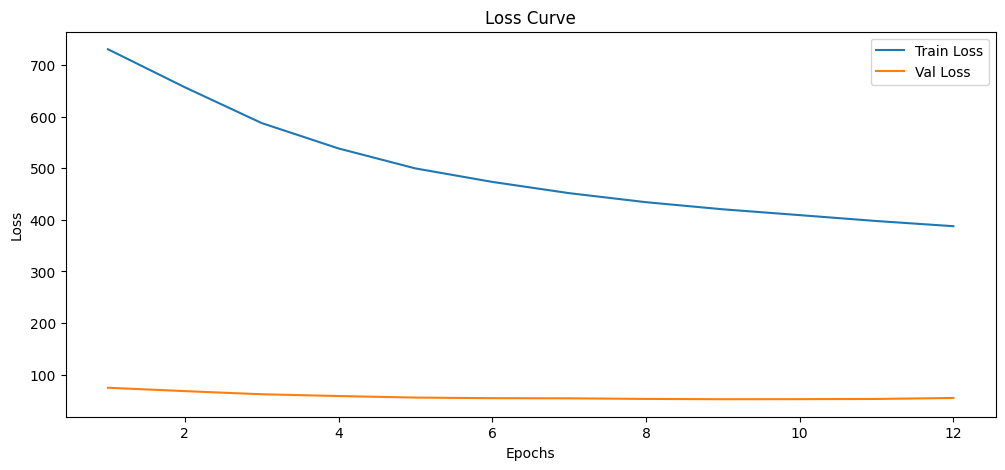

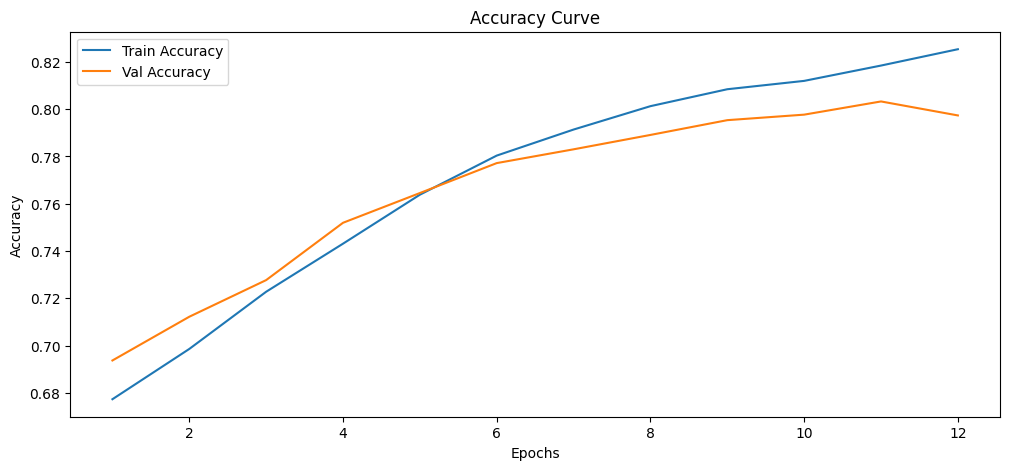

In [13]:
# Plot Training Curves
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12,5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

In [17]:
# Evaluation (Accuracy, EM, F1)
from sklearn.metrics import accuracy_score, f1_score

model.load_state_dict(torch.load("best_bilstm.pt"))
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = model(X)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y.numpy())

acc = accuracy_score(all_true, all_preds)
macro_f1 = f1_score(all_true, all_preds, average='macro')
f1_per_class = f1_score(all_true, all_preds, average=None)
em = acc  # for single label classification EM = accuracy

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("F1 per class:", f1_per_class)
print("EM:", em)

Accuracy: 0.7894473618404602
Macro F1: 0.5570567246998105
F1 per class: [0.40439733 0.24       0.71392405 0.86990552]
EM: 0.7894473618404602


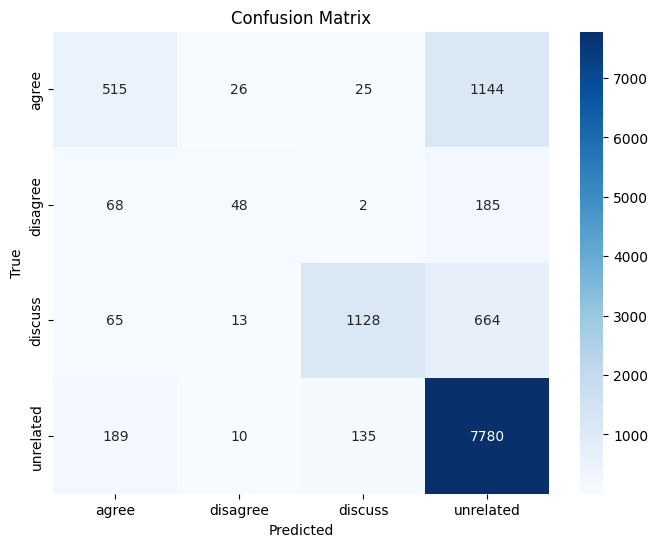

In [15]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [18]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(all_true, all_preds, target_names=le.classes_))

              precision    recall  f1-score   support

       agree       0.62      0.30      0.40      1710
    disagree       0.49      0.16      0.24       303
     discuss       0.87      0.60      0.71      1870
   unrelated       0.80      0.96      0.87      8114

    accuracy                           0.79     11997
   macro avg       0.70      0.51      0.56     11997
weighted avg       0.77      0.79      0.76     11997



In [19]:
# AUC / ROC Curves (per class + macro AUC)
from sklearn.metrics import roc_auc_score
import numpy as np

model.eval()
probs = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.cuda()
        logits = model(X)
        p = torch.softmax(logits, dim=1).cpu().numpy()
        probs.append(p)

probs = np.vstack(probs)
y_true_oh = np.zeros((len(all_true), num_classes))
for i, label in enumerate(all_true):
    y_true_oh[i][label] = 1

auc_per_class = roc_auc_score(y_true_oh, probs, average=None)
auc_macro = roc_auc_score(y_true_oh, probs, average="macro")

print("AUC per class:", dict(zip(le.classes_, auc_per_class)))
print("Macro AUC:", auc_macro)

AUC per class: {'agree': np.float64(0.8196837602901977), 'disagree': np.float64(0.8221953544764431), 'discuss': np.float64(0.8877880859607055), 'unrelated': np.float64(0.85478452144502)}
Macro AUC: 0.8461129305430917


In [20]:
# Top-K Accuracy (Top-3 & Top-5)
import numpy as np

def top_k_accuracy(probs, true_labels, k):
    topk = np.argsort(probs, axis=1)[:, -k:]
    correct = 0
    for i in range(len(true_labels)):
        if true_labels[i] in topk[i]:
            correct += 1
    return correct / len(true_labels)

top3 = top_k_accuracy(probs, all_true, k=3)
top5 = top_k_accuracy(probs, all_true, k=5)

print("Top-3 Accuracy:", top3)
print("Top-5 Accuracy:", top5)

Top-3 Accuracy: 0.9819954988747187
Top-5 Accuracy: 1.0


In [22]:
# Save Model
import pickle

save_objects = {
    "vocab": vocab,
    "label_encoder": le,
    "max_len": max_len
}

with open("bilstm_assets.pkl", "wb") as f:
    pickle.dump(save_objects, f)

print("Saved vocab, label encoder, and sequence length.")


Saved vocab, label encoder, and sequence length.


In [23]:
# Load the Saved Model
import pickle
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load tokenizer objects
with open("bilstm_assets.pkl", "rb") as f:
    assets = pickle.load(f)

vocab = assets["vocab"]
label_encoder = assets["label_encoder"]
max_len = assets["max_len"]

# Load model
model = AttentionBiLSTM(
    vocab_size=len(vocab),
    embedding_dim=embedding_dim,
    hidden_dim=256,
    num_classes=len(label_encoder.classes_),
    embedding_matrix=embedding_matrix
).to(device)

model.load_state_dict(torch.load("best_bilstm.pt", map_location=device))
model.eval()

print("Model + preprocessing loaded successfully.")

Model + preprocessing loaded successfully.


In [24]:
def encode_tokens(tokens):
    return [vocab.get(t, vocab["<UNK>"]) for t in tokens]

def pad_seq(seq):
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [0] * (max_len - len(seq))

def predict_stance(headline, body):
    text = headline + " " + body
    tokens = tokenize(text)
    seq = encode_tokens(tokens)
    seq = pad_seq(seq)

    X = torch.tensor([seq], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(X)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = probs.argmax()
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    return pred_label, probs


In [42]:
headline = "Electric cars reduce pollution significantly"

# Example bodies for all 4 classes:

# Agree
body_agree = "Electric cars clearly reduce pollution according to multiple environmental reports."

# Disagree
body_disagree = "Study shows that electric cars will not reduce pollution due to emissions from electricity generation."

# Discuss
body_discuss = "While electric cars could reduce pollution, there are debates on battery production impact and electricity sources."

# Unrelated
body_unrelated = "The city's football team won the championship last night."

# Example usage:
label_agree, probs_agree = predict_stance(headline, body_agree)
label_disagree, probs_disagree = predict_stance(headline, body_disagree)
label_discuss, probs_discuss = predict_stance(headline, body_discuss)
label_unrelated, probs_unrelated = predict_stance(headline, body_unrelated)

print("Agree Prediction:", label_agree, "Confidence:", probs_agree)
print("Disagree Prediction:", label_disagree, "Confidence:", probs_disagree)
print("Discuss Prediction:", label_discuss, "Confidence:", probs_discuss)
print("Unrelated Prediction:", label_unrelated, "Confidence:", probs_unrelated)

Agree Prediction: unrelated Confidence: [0.23858339 0.15634531 0.21215567 0.39291564]
Disagree Prediction: agree Confidence: [0.31092745 0.17274082 0.27970815 0.23662359]
Discuss Prediction: agree Confidence: [7.0222831e-01 9.4083488e-02 2.0306900e-01 6.1924965e-04]
Unrelated Prediction: unrelated Confidence: [0.18112367 0.11507862 0.17784578 0.5259519 ]


In [43]:
headline = "ISIS: Desperate mum told 'you've just eaten your son' after visiting militants' base in search of kidnap victim"

body = """Islamic State fighters fed the mum cooked meat and rice before telling her it was the remains of her kidnapped son, a British dad who went to fight IS has revealed

Sick ISIS militants fed a desperate mum the mutilated remains of her son - after telling her it was cooked meat and rice, it was claimed today.

The son had been captured and taken prisoner by Islamic State militants in Mosul, Iraq.

The worried mum then bravely visited the terror group's headquarters in a bid to speak to her loved one.

ISIS fighters told the mum she should eat before seeing her son because she had travelled a long way.

However, after giving the mother cooked meat, rice and soup, she was horrified to be told she had just eaten her son.

British dad Yasir Abdulla, who left his home in Keighley, West Yorkshire to fight against ISIS, said he joined the battle against the terror group after being told this story.

Ben Lack   Inspired: Yasir Abdulla went to fight ISIS after hearing this story

He said: "The ISIS men told her to sit down because she had travelled a long way and said she should have some food before they took her to meet her son.

"But they had killed him and chopped him up and after she finished the meal and asked to see her son they laughed and said, 'You've just eaten him'."

And after witnessing the horrors of the terror group up close, Yasir says they have 'hijacked Islam'.

"ISIS are wrong. They behead, burn and get those they are against do dig their own graves before they execute them," he said.

"Nobody wants to get captured by ISIS, that would be the worst thing. If I was defending I would fight to my last bullet and use that on myself."

Yasir is aware of Brits joining ISIS but has not encountered any in battle. "I have seen what Jihad John has done and I think that person needs to be captured and executed," he said.

VIEW GALLERY

"England is a lovely place, the people are lovely and the Government is good. Whatever the British joining ISIS say is wrong about Britain, they just hate.

"They are not Muslims, they have hijacked Islam. Muslim people should not cut the head off an animal in front of another animal, but these ISIS behead people every day in front of other people."

The incident is the latest atrocity from the terror group.

It emerged this weekend that Islamic State militants blindfolded a 'gay' man, threw him from a roof then stoned his corpse in Syria.

Horrific images revealed by ISIS show the barbaric killing in front of a baying crowd carried out at a building in Raqqa.

It is believed the man was sentenced to death by a sharia court.

The man was described as being a 'child of Lot' and accused of committing acts of sodomy, according to the Daily Mail.

'Lot' is a reference to a prophet of God whose story in the Qu'ran is used to demonstrate Islam's supposed disapproval of rape and homosexuality.

#ISIS stoned a man to death in Tal Abiad in #Raqqa for being homosexual after throwing him from the roof of the Islamic Court building.— الرقة تذبح بصمت (@Raqqa_Sl) February 27, 2015

The images appear to show the man was blindfolded and had his feet tied before being hurled onto rubble from a tall building.

Crowds then gather round and pelt the corpse with rocks.

It was the fourth time in a few weeks that the jihadist group has used the brutal execution method for alleged homosexuality .

After claiming they found videos on his mobile phone showing him 'practising indecent acts with males,' a 20-year old man was stoned to death in the Syrian province of Deir Ezzor in late November, according to the Syrian Observatory for Human Rights.

Video loading"""

label5, probs5 = predict_stance(headline, body)
print("Prediction:", label5)
print("Confidence:", probs5)

Prediction: agree
Confidence: [0.7239207  0.11252859 0.16268304 0.00086773]
